## One Image per class

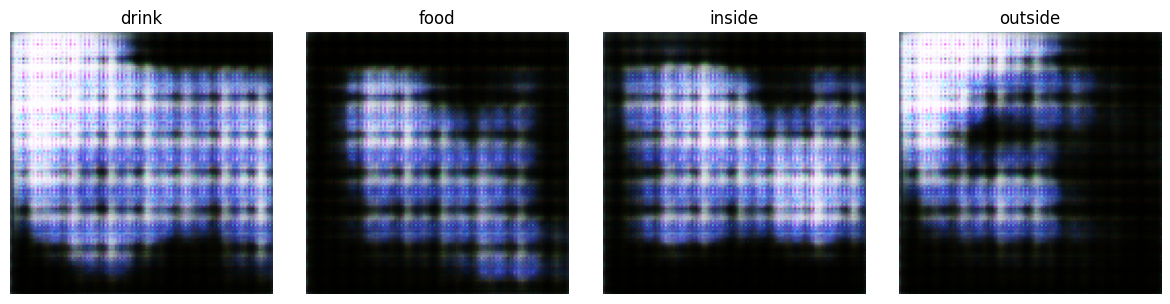

In [ ]:
generate_images_by_label(generator, class_names)

## Install Required Packages

In [3]:
!pip install tensorflow matplotlib scipy

   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   - -------------------------------------- 1.8/41.3 MB 11.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.5/41.3 MB 12.2 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/41.3 MB 10.7 MB/s eta 0:00:04
   ------- -------------------------------- 8.1/41.3 MB 10.1 MB/s eta 0:00:04
   ---------- ----------------------------- 10.7/41.3 MB 10.3 MB/s eta 0:00:03
   ------------ --------------------------- 13.1/41.3 MB 10.7 MB/s eta 0:00:03
   -------------- ------------------------- 15.5/41.3 MB 10.6 MB/s eta 0:00:03
   ---------------- ----------------------- 17.3/41.3 MB 10.6 MB/s eta 0:00:03
   ------------------- -------------------- 19.7/41.3 MB 10.4 MB/s eta 0:00:03
   --------------------- ------------------ 22.0/41.3 MB 10.5 MB/s eta 0:00:02
   ----------------------- ---------------- 24.6/41.3 MB 10.5 MB/s eta 0:00:02
   ------------------------- -------------- 26.7/41.3 MB 10.6 MB/

##Imports and Constants

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from scipy.stats import entropy
import numpy as np
import matplotlib.pyplot as plt
import os
import time

## Configurations

In [23]:
# Options: "fast", "balanced", "full"
MODE = "balanced"

# ========== FIXED SETTINGS ==========
IMG_CHANNELS = 3
DATA_PATH = "./final_processed_data/final_processed_data/train"
NUM_CLASSES = 4
LATENT_DIM = 100
SAVE_MODEL = True
SAVE_IMAGES_EACH_EPOCH = True
MODEL_SAVE_PATH = "cgan_generator_final.h5"

# ========== FAST MODE ==========
if MODE == "fast":
    IMG_HEIGHT = 112
    IMG_WIDTH = 112
    BATCH_SIZE = 32
    EPOCHS = 3
    LIMIT_BATCHES = 30  # ~5-10 mins
    MODEL_SAVE_PATH = "cgan_generator_final_fast.h5"

# ========== BALANCED MODE (RECOMMENDED) ==========
elif MODE == "balanced":
    IMG_HEIGHT = 128
    IMG_WIDTH = 128
    BATCH_SIZE = 32
    EPOCHS = 10
    LIMIT_BATCHES = 100  # ~30-40 mins
    MODEL_SAVE_PATH = "cgan_generator_final_balanced.h5"

# ========== FULL MODE ==========
elif MODE == "full":
    IMG_HEIGHT = 224
    IMG_WIDTH = 224
    BATCH_SIZE = 64
    EPOCHS = 50
    LIMIT_BATCHES = None
    MODEL_SAVE_PATH = "cgan_generator_final_full.h5"

else:
    raise ValueError("❌ Invalid MODE. Choose from: 'fast', 'balanced', 'full'")

##Load and Preprocess Dataset

In [24]:
# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    label_mode='int',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Store class names early
class_names = train_ds.class_names

# Normalize to [-1, 1]
def preprocess(images, labels):
    images = tf.cast(images, tf.float32)
    images = (images / 127.5) - 1.0
    return images, labels

train_ds = train_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

# Optional: sample subset
if LIMIT_BATCHES:
    train_ds = train_ds.take(LIMIT_BATCHES)


Found 18599 files belonging to 4 classes.


## Generator

In [25]:
from tensorflow.keras import layers, Model, Input

def build_generator(latent_dim=100, num_classes=4, img_shape=(128, 128, 3)):
    noise_input = Input(shape=(latent_dim,), name="noise_input")
    label_input = Input(shape=(1,), dtype='int32', name="label_input")

    # Embed label and combine with noise
    label_embedding = layers.Embedding(num_classes, latent_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    conditioned_input = layers.Multiply()([noise_input, label_embedding])

    x = layers.Dense(7 * 7 * 256, use_bias=False)(conditioned_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((7, 7, 256))(x)

    x = layers.Conv2DTranspose(128, kernel_size=5, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(32, kernel_size=5, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Final layer to get 3-channel output (tanh activation)
    x = layers.Conv2DTranspose(3, kernel_size=5, strides=2, padding='same', activation='tanh')(x)

    # ✅ Resize using Keras-compatible layer
    x = layers.Resizing(img_shape[0], img_shape[1])(x)

    generator = Model([noise_input, label_input], x, name="Generator")
    return generator

##Discriminator

In [26]:
def build_discriminator(num_classes=NUM_CLASSES, img_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    image_input = layers.Input(shape=img_shape)
    label_input = layers.Input(shape=(1,), dtype='int32')

    label_embedding = layers.Embedding(num_classes, img_shape[0] * img_shape[1])(label_input)
    label_embedding = layers.Reshape((img_shape[0], img_shape[1], 1))(label_embedding)

    x = layers.Concatenate()([image_input, label_embedding])

    x = layers.Conv2D(64, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1, activation='sigmoid')(x)

    return models.Model([image_input, label_input], x, name="Discriminator")


## Loss, Optimizers, Training Step

In [27]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator = build_generator()
discriminator = build_discriminator()

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images, labels):
    labels = tf.cast(tf.reshape(labels, (-1, 1)), tf.int32)
    noise = tf.random.normal([tf.shape(images)[0], LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, labels], training=True)

        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return gen_loss, disc_loss


## Image Sampling Utility

In [28]:
def generate_and_save_images(generator, epoch, class_names):
    noise = tf.random.normal([NUM_CLASSES, LATENT_DIM])
    labels = tf.range(NUM_CLASSES)[:, tf.newaxis]
    generated_images = generator([noise, labels], training=False)
    generated_images = (generated_images + 1) / 2.0

    fig, axs = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 2, 2))
    for i in range(NUM_CLASSES):
        axs[i].imshow(generated_images[i])
        axs[i].axis("off")
        axs[i].set_title(class_names[i])
    plt.tight_layout()
    plt.savefig(f"cgan_sample_epoch_{epoch+1}.png")
    plt.close()


## Full Training Loop

In [29]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()
        gen_losses, disc_losses = [], []

        for image_batch, label_batch in dataset:
            g_loss, d_loss = train_step(image_batch, label_batch)
            gen_losses.append(g_loss)
            disc_losses.append(d_loss)

        print(f"Epoch {epoch+1}/{epochs} | Gen Loss: {tf.reduce_mean(gen_losses):.4f} | Disc Loss: {tf.reduce_mean(disc_losses):.4f} | Time: {time.time()-start:.2f}s")

        if SAVE_IMAGES_EACH_EPOCH:
            generate_and_save_images(generator, epoch, class_names)

    if SAVE_MODEL:
        generator.save(MODEL_SAVE_PATH)
        print(f"✅ Generator model saved to: {MODEL_SAVE_PATH}")


## Start Training

In [30]:
train(train_ds, EPOCHS)

Epoch 1/10 | Gen Loss: 2.8838 | Disc Loss: 0.4713 | Time: 163.72s
Epoch 2/10 | Gen Loss: 2.5453 | Disc Loss: 0.4424 | Time: 154.48s
Epoch 3/10 | Gen Loss: 2.9177 | Disc Loss: 0.4848 | Time: 147.54s
Epoch 4/10 | Gen Loss: 4.0557 | Disc Loss: 0.5120 | Time: 148.10s
Epoch 5/10 | Gen Loss: 2.7828 | Disc Loss: 0.5650 | Time: 147.72s
Epoch 6/10 | Gen Loss: 2.7200 | Disc Loss: 0.3882 | Time: 148.78s
Epoch 7/10 | Gen Loss: 3.3196 | Disc Loss: 0.4378 | Time: 147.63s
Epoch 8/10 | Gen Loss: 3.0502 | Disc Loss: 0.7553 | Time: 147.40s
Epoch 9/10 | Gen Loss: 3.1763 | Disc Loss: 0.3698 | Time: 147.35s
Epoch 10/10 | Gen Loss: 2.6379 | Disc Loss: 0.6843 | Time: 147.31s


✅ Generator model saved to: cgan_generator_final_balanced.h5


## Generate Images for Each Label

In [31]:
def generate_images_by_label(generator, class_names, latent_dim=LATENT_DIM):
    os.makedirs("cgan_final_outputs", exist_ok=True)

    noise = tf.random.normal([NUM_CLASSES, latent_dim])
    labels = tf.range(NUM_CLASSES)[:, tf.newaxis]

    generated_images = generator([noise, labels], training=False)
    generated_images = (generated_images + 1) / 2.0  # Rescale to [0, 1]

    fig, axs = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 3, 3))
    for i in range(NUM_CLASSES):
        axs[i].imshow(generated_images[i])
        axs[i].axis('off')
        axs[i].set_title(class_names[i])
        plt.imsave(f"cgan_final_outputs/class_{class_names[i]}.png", generated_images[i].numpy())
    plt.tight_layout()
    plt.savefig("cgan_final_outputs/cgan_generated_grid.png")
    plt.show()

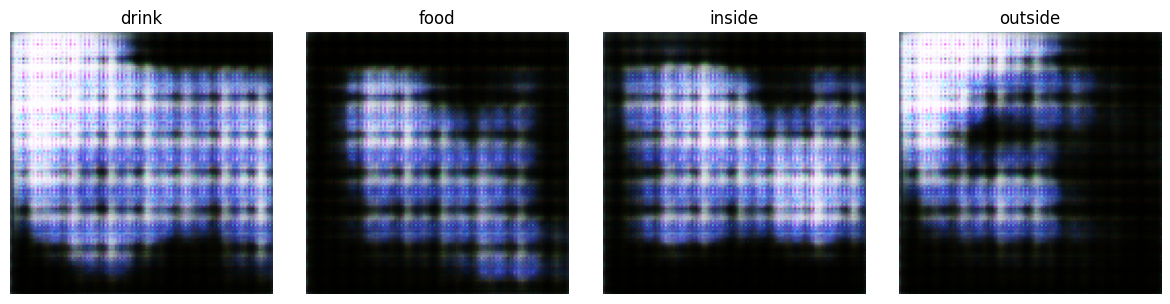

In [32]:
generate_images_by_label(generator, class_names)

## Inception Score Utility

In [33]:
# Load pretrained InceptionV3 model
inception_model = InceptionV3(include_top=True, weights='imagenet', pooling='avg')

def calculate_inception_score(images, splits=10):
    # Step 1: Resize and preprocess
    images = tf.image.resize(images, (299, 299))
    images = preprocess_input(images * 255.0)

    # Step 2: Predict with InceptionV3
    preds = inception_model.predict(images, verbose=0)
    preds = tf.nn.softmax(preds).numpy()

    # Step 3: Split into parts and compute KL divergence
    split_scores = []
    N = preds.shape[0]
    for k in range(splits):
        part = preds[k * N // splits: (k+1) * N // splits]
        py = np.mean(part, axis=0)
        scores = [entropy(p, py) for p in part]
        split_scores.append(np.exp(np.mean(scores)))

    # Final Inception Score
    return np.mean(split_scores), np.std(split_scores)

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


## Generate Images for IS Evaluation

In [34]:
# Generate 100 images across all labels
n_images = 100
noise = tf.random.normal([n_images, LATENT_DIM])
labels = tf.random.uniform([n_images, 1], minval=0, maxval=NUM_CLASSES, dtype=tf.int32)

generated_images = generator([noise, labels], training=False)
generated_images = (generated_images + 1.0) / 2.0  # Rescale to [0, 1]

## Compute & Print Inception Score

In [35]:
mean_is, std_is = calculate_inception_score(generated_images, splits=5)
print(f"📈 Inception Score (IS): {mean_is:.4f} ± {std_is:.4f}")

📈 Inception Score (IS): 1.0001 ± 0.0000
